# 目的関数の描画

実験で扱った勾配降下法の目的関数 $f(x) = (x^2 - 1)^2$ のグラフは以下の通り．
明らかに，$x = \pm 1$で最小値をとる．

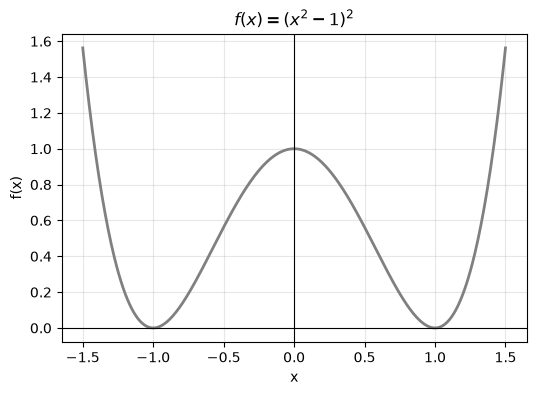

In [1]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-1.5, 1.5, 400)
y = (x**2 - 1) ** 2

plt.figure(figsize=(6, 4))
plt.plot(x, y, label=r'$f(x)=(x^2-1)^2$', color='gray', linewidth=2)
plt.axhline(0, color='black', linewidth=0.8)
plt.axvline(0, color='black', linewidth=0.8)
plt.grid(True, alpha=0.3)
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title(r'$f(x)=(x^2-1)^2$')
plt.savefig("../out/objective_function_plot.png", dpi=300)
plt.show()

# $f$ に対する勾配降下法の写像のパラメータ変化に伴う振る舞い

# 

In [2]:
# f(x) = (x^2 - 1)^2 に対する勾配降下法の写像

def gd_map(x, eta):
    return (1.0 + 4.0 * eta) * x - 4.0 * eta * x**3

勾配降下法の写像 $F_{\eta}(x) = -4 \eta x^3 + (4\eta + 1) x$ は，学習率 $\eta$ が $1/2$ を超えると
$F_\eta([-R_\eta, R_\eta]) \subset [-R_\eta, R_\eta]$ を満たさなくなる．ただし，$R_\eta = \sqrt{(2\eta + 1)/(2\eta)}$.

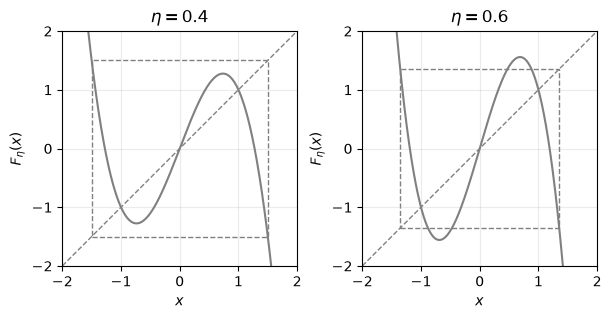

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path


def plot_gd_map_with_squares(output_path=None):
    etas = [0.4, 0.6]
    x = np.linspace(-2.0, 2.0, 800)

    fig, axes = plt.subplots(1, 2, figsize=(6, 6), constrained_layout=True)

    for ax, eta in zip(axes, etas):
        y = gd_map(x, eta)
        R_eta = np.sqrt((2.0 * eta + 1.0) / (2.0 * eta))

        ax.plot(x, y, color="gray", linewidth=1.5)
        ax.plot(x, x, color="gray", linestyle="--", linewidth=1.0)

        square = patches.Rectangle(
            (-R_eta, -R_eta),
            2.0 * R_eta,
            2.0 * R_eta,
            edgecolor="gray",
            facecolor="none",
            linestyle="--",
            linewidth=1.0,
        )
        ax.add_patch(square)

        ax.set_title(rf'$\eta = {eta}$')
        ax.set_xlim(-2.0, 2.0)
        ax.set_ylim(-2.0, 2.0)
        ax.set_aspect("equal", adjustable="box")
        ax.set_xticks(np.arange(-2, 2.1, 1.0))
        ax.set_yticks(np.arange(-2, 2.1, 1.0))
        ax.set_xlabel(r'$x$')
        ax.set_ylabel(r'$F_\eta(x)$')
        ax.grid(alpha=0.25)

    if output_path is not None:
        output_path = Path(output_path)
        output_path.parent.mkdir(exist_ok=True, parents=True)
        fig.savefig(output_path, dpi=300, bbox_inches="tight")

    plt.show()


plot_gd_map_with_squares(output_path="../out/gd_map_with_squares.png")


# 吸引領域と並記した描画

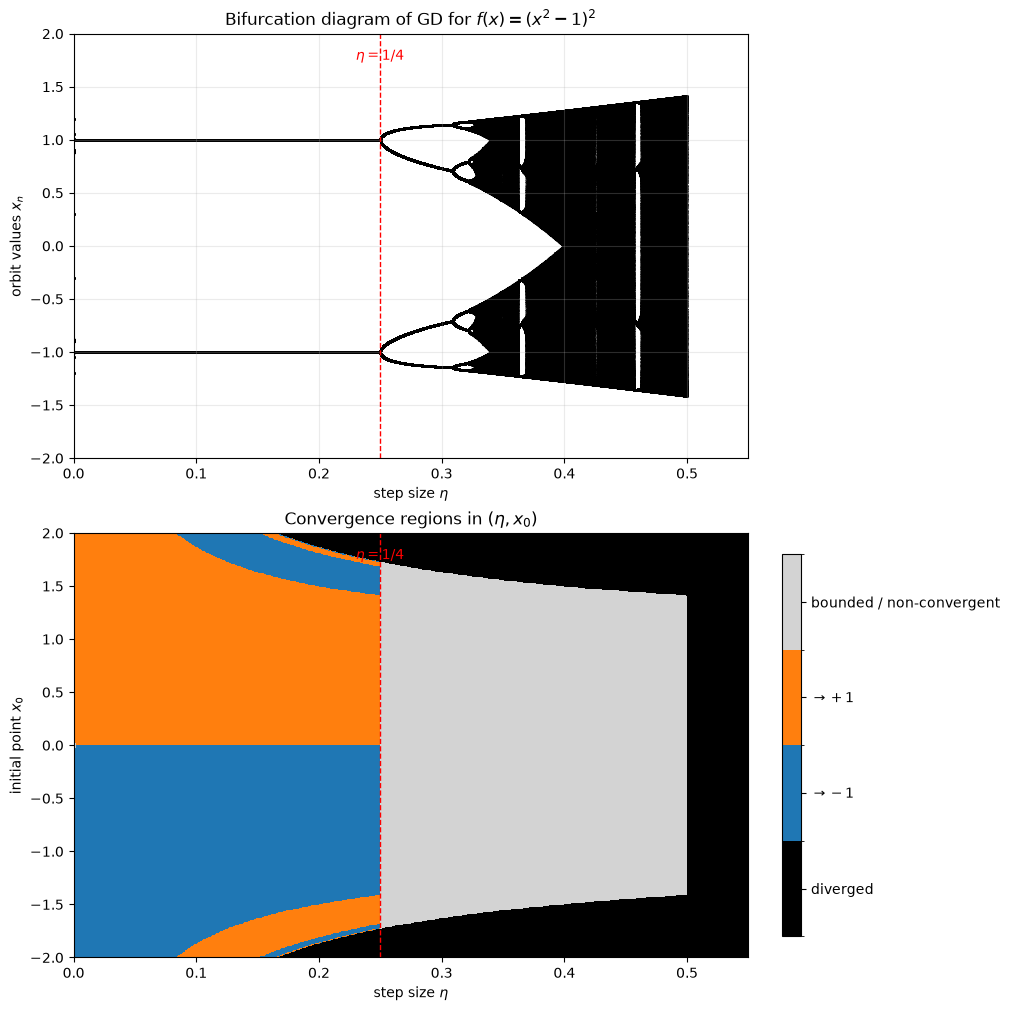

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm


# ============================================================
# 1. Bifurcation diagram
# ============================================================

def compute_bifurcation(
    eta_min=0.0,
    eta_max=0.55,
    n_eta=2500,
    x0_values=None,
    burn_in=2000,
    keep=300,
    escape_radius=1e6,
):
    """
    Returns arrays (etas_plot, xs_plot) for bifurcation diagram.

    Important:
    x0 = ±1 are fixed for all eta, so if we start exactly from ±1,
    we do not see the unstable branches after period doubling.
    Therefore we use initial points near ±1, plus several other points.
    """

    etas = np.linspace(eta_min, eta_max, n_eta)

    if x0_values is None:
        x0_values = np.array([
            -1.2, -1.05, -1.001, -0.999, -0.9,
            -0.3, 0.3,
            0.9, 0.999, 1.001, 1.05, 1.2,
        ])

    eta_list = []
    x_list = []

    for eta in etas:
        x = x0_values.astype(float).copy()
        alive = np.ones_like(x, dtype=bool)

        # burn-in
        for _ in range(burn_in):
            x[alive] = gd_map(x[alive], eta)

            bad = ~np.isfinite(x) | (np.abs(x) > escape_radius)
            alive &= ~bad

            if not np.any(alive):
                break

        # keep last iterates
        for _ in range(keep):
            if not np.any(alive):
                break

            x[alive] = gd_map(x[alive], eta)

            bad = ~np.isfinite(x) | (np.abs(x) > escape_radius)
            alive &= ~bad

            vals = x[alive]
            eta_list.append(np.full(vals.shape, eta))
            x_list.append(vals.copy())

    if len(eta_list) == 0:
        return np.array([]), np.array([])

    return np.concatenate(eta_list), np.concatenate(x_list)


# ============================================================
# 2. Convergence / basin map
# ============================================================

def classify_orbit(
    x0,
    eta,
    n_iter=3000,
    tol=1e-6,
    escape_radius=1e6,
):
    """
    Classification labels:

        0 : diverged / escaped
        1 : converges to -1
        2 : converges to +1
        3 : bounded but not converged to ±1 in n_iter steps

    For eta > 1/4, ±1 are no longer attracting, so many bounded points
    are classified as 3.
    """

    x = float(x0)

    for _ in range(n_iter):
        x = gd_map(x, eta)

        if (not np.isfinite(x)) or abs(x) > escape_radius:
            return 0

    if abs(x + 1.0) < tol:
        return 1

    if abs(x - 1.0) < tol:
        return 2

    return 3


def compute_basin(
    eta_min=0.0,
    eta_max=0.55,
    n_eta=700,
    x_min=-2.0,
    x_max=2.0,
    n_x=700,
    n_iter=3000,
    tol=1e-6,
    escape_radius=1e6,
):
    etas = np.linspace(eta_min, eta_max, n_eta)
    xs = np.linspace(x_min, x_max, n_x)
    eta_grid = np.broadcast_to(etas[np.newaxis, :], (n_x, n_eta))
    x = np.broadcast_to(xs[:, np.newaxis], (n_x, n_eta)).astype(float)
    alive = np.ones_like(x, dtype=bool)

    for _ in range(n_iter):
        if not np.any(alive):
            break

        x[alive] = gd_map(x[alive], eta_grid[alive])

        bad = ~np.isfinite(x) | (np.abs(x) > escape_radius)
        alive &= ~bad

    basin = np.full((n_x, n_eta), 3, dtype=np.int8)
    escaped = ~np.isfinite(x) | (np.abs(x) > escape_radius)
    basin[escaped] = 0
    basin[(np.abs(x + 1.0) < tol) & ~escaped] = 1
    basin[(np.abs(x - 1.0) < tol) & ~escaped] = 2

    return etas, xs, basin


# ============================================================
# 3. Plot side by side
# ============================================================

def plot_bifurcation_and_basin():
    eta_min = 0.0
    eta_max = 0.55

    # ---- bifurcation ----
    etas_bif, xs_bif = compute_bifurcation(
        eta_min=eta_min,
        eta_max=eta_max,
        n_eta=2500,
        burn_in=2000,
        keep=150,
    )

    # ---- basin / convergence map ----
    etas_grid, xs_grid, basin = compute_basin(
        eta_min=eta_min,
        eta_max=eta_max,
        n_eta=650,
        x_min=-2.0,
        x_max=2.0,
        n_x=650,
        n_iter=3000,
    )

    # label colors:
    # 0: diverged
    # 1: converges to -1
    # 2: converges to +1
    # 3: bounded but not converged
    cmap = ListedColormap([
        "black",      # diverged
        "tab:blue",   # -> -1
        "tab:orange", # -> +1
        "lightgray",  # bounded non-convergent
    ])
    norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5], cmap.N)

    fig, axes = plt.subplots(2, 1, figsize=(10, 10), constrained_layout=True)

    # --------------------------------------------------------
    # Top: bifurcation diagram
    # --------------------------------------------------------
    ax = axes[0]
    ax.scatter(
        etas_bif,
        xs_bif,
        s=0.03,
        color="black",
        alpha=0.5,
        rasterized=True,
    )

    ax.axvline(1 / 4, color="red", linestyle="--", linewidth=1)
    ax.text(
        1 / 4,
        1.85,
        r"$\eta=1/4$",
        color="red",
        ha="center",
        va="top",
    )

    ax.set_title(r"Bifurcation diagram of GD for $f(x)=(x^2-1)^2$")
    ax.set_xlabel(r"step size $\eta$")
    ax.set_ylabel(r"orbit values $x_n$")
    ax.set_xlim(eta_min, eta_max)
    ax.set_ylim(-2.0, 2.0)
    ax.grid(alpha=0.25)

    # --------------------------------------------------------
    # Bottom: convergence / basin map
    # --------------------------------------------------------
    ax = axes[1]
    im = ax.imshow(
        basin,
        origin="lower",
        aspect="auto",
        extent=[eta_min, eta_max, xs_grid[0], xs_grid[-1]],
        cmap=cmap,
        norm=norm,
        interpolation="nearest",
    )

    ax.axvline(1 / 4, color="red", linestyle="--", linewidth=1)
    ax.text(
        1 / 4,
        1.85,
        r"$\eta=1/4$",
        color="red",
        ha="center",
        va="top",
    )

    ax.set_title(r"Convergence regions in $(\eta,x_0)$")
    ax.set_xlabel(r"step size $\eta$")
    ax.set_ylabel(r"initial point $x_0$")
    ax.set_xlim(eta_min, eta_max)
    ax.set_ylim(-2.0, 2.0)

    cbar = fig.colorbar(
        im,
        ax=ax,
        ticks=[0, 1, 2, 3],
        shrink=0.9,
    )
    cbar.ax.set_yticklabels([
        "diverged",
        r"$\to -1$",
        r"$\to +1$",
        "bounded / non-convergent",
    ])

    plt.show()


if __name__ == "__main__":
    plot_bifurcation_and_basin()
